In [5]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

# Find the project root (the nearest ancestor that contains `src`) and add it to sys.path
cwd = Path.cwd()
project_root = cwd
for _ in range(6):
    if (project_root / "src").exists():
        break
    if project_root.parent == project_root:
        break
    project_root = project_root.parent
else:
    project_root = cwd

proj_path = str(project_root.resolve())
if proj_path not in sys.path:
    # Insert at front so local packages take precedence
    sys.path.insert(0, proj_path)

import aerosandbox.numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from src.airfoil.compute_airfoil_quality import compute_airfoil_quality, QualityError

import aerosandbox as asb
from aerosandbox import Airfoil
from src.airfoil import airfoil_modifications

import plotly.express as px

import src.plotting as plotting

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
airfoil = Airfoil(name="s1223")
airfoil = airfoil.repanel(n_points_per_side=35)
# airfoil.draw(show=False, fill=False)
airfoil.draw(draw_markers=True, backend="plotly", save_path="./images/s1223_plotly.pdf")

Gráfico salvo com sucesso em: ./images/s1223_plotly.pdf


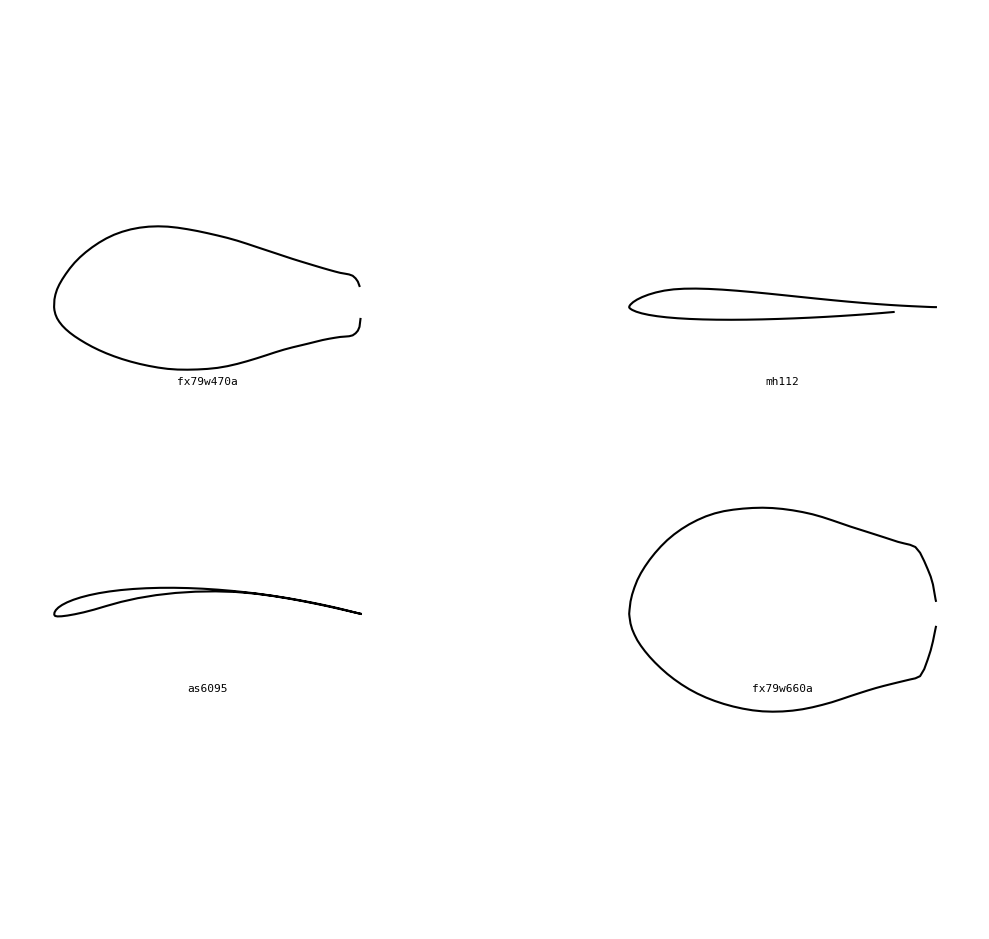

In [13]:
removed_airfoils = ["fx79w470a", "mh112", "as6095", "fx79w660a"]

airfoils = [asb.Airfoil(name) for name in removed_airfoils]

plotting.plot_airfoil_list(airfoils, color="black", save_path="./images", labels=removed_airfoils, filename="removed_airfoils.png")